# DATASCI 503, Homework 6: Splines and Smoothing

This assignment covers **regression splines** (piecewise polynomials joined at knots), **smoothing splines** (which balance fit and smoothness via a penalty term), and **generalized additive models (GAMs)** that extend these ideas to multiple predictors.

---

**Problem 1 (ISLP Ch 7, Exercise 1):** Piecewise Cubic Functions

It was mentioned in this chapter that a cubic regression spline with one knot at $\xi$ can be obtained using a basis of the form $x$, $x^2$, $x^3$, $(x - \xi)^3_+$, where $(x - \xi)^3_+ = (x - \xi)^3$ if $x > \xi$ and equals 0 otherwise. We will now show that a function of the form

$$f(x) = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + \beta_4 (x - \xi)^3_+$$

is indeed a cubic regression spline, regardless of the values of $\beta_0$, $\beta_1$, $\beta_2$, $\beta_3$, $\beta_4$.

**(a)** Find a cubic polynomial

$$f_1(x) = a_1 + b_1 x + c_1 x^2 + d_1 x^3$$

such that $f(x) = f_1(x)$ for all $x \leq \xi$. Express $a_1$, $b_1$, $c_1$, $d_1$ in terms of $\beta_0$, $\beta_1$, $\beta_2$, $\beta_3$, $\beta_4$.

If $x \le \xi$, then $(x-\xi)^3_+=0$. Therefore

$$
f_1(x)=\beta_0+\beta_1x+\beta_2x^2+\beta_3x^3.
$$

Thus

$$
a_1=\beta_0, \quad
b_1=\beta_1, \quad
c_1=\beta_2, \quad
d_1=\beta_3.
$$

**(b)** Find a cubic polynomial

$$f_2(x) = a_2 + b_2 x + c_2 x^2 + d_2 x^3$$

such that $f(x) = f_2(x)$ for all $x > \xi$. Express $a_2$, $b_2$, $c_2$, $d_2$ in terms of $\beta_0$, $\beta_1$, $\beta_2$, $\beta_3$, $\beta_4$. We have now established that $f(x)$ is a piecewise polynomial.

If $x > \xi$, then

$$
(x-\xi)^3 = x^3 - 3\xi x^2 + 3\xi^2 x - \xi^3.
$$

So

$$
\begin{aligned}
f_2(x)
&= \beta_0+\beta_1x+\beta_2x^2+\beta_3x^3
+ \beta_4(x^3 - 3\xi x^2 + 3\xi^2 x - \xi^3) \\
&= (\beta_0-\beta_4\xi^3)
+(\beta_1+3\beta_4\xi^2)x
+(\beta_2-3\beta_4\xi)x^2
+(\beta_3+\beta_4)x^3.
\end{aligned}
$$

Therefore

$$
a_2=\beta_0-\beta_4\xi^3, \quad
b_2=\beta_1+3\beta_4\xi^2, \quad
c_2=\beta_2-3\beta_4\xi, \quad
d_2=\beta_3+\beta_4.
$$


**(c)** Show that $f_1(\xi) = f_2(\xi)$. That is, $f(x)$ is continuous at $\xi$.

Recall
- For $x \le \xi$: $f_1(x)=\beta_0+\beta_1x+\beta_2x^2+\beta_3x^3$.
- For $x > \xi$: $f_2(x)=\beta_0+\beta_1x+\beta_2x^2+\beta_3x^3+\beta_4(x-\xi)^3$.

At $x=\xi$, we have $(\xi-\xi)^3=0$, so
$f_2(\xi)=\beta_0+\beta_1\xi+\beta_2\xi^2+\beta_3\xi^3=f_1(\xi)$.
Thus $f$ is continuous at $\xi$.

**(d)** Show that $f_1'(\xi) = f_2'(\xi)$. That is, $f'(x)$ is continuous at $\xi$.

Differentiate on each side:
- For $x \le \xi$,
$f_1'(x)=\beta_1+2\beta_2x+3\beta_3x^2$.
- For $x > \xi$,
$f_2'(x)=\beta_1+2\beta_2x+3\beta_3x^2+3\beta_4(x-\xi)^2$.

At $x=\xi$, $(\xi-\xi)^2=0$, so
$f_2'(\xi)=\beta_1+2\beta_2\xi+3\beta_3\xi^2=f_1'(\xi)$.
Hence $f'$ is continuous at $\xi$.

**(e)** Show that $f_1''(\xi) = f_2''(\xi)$. That is, $f''(x)$ is continuous at $\xi$.

Therefore, $f(x)$ is indeed a cubic spline.

*Hint: Parts (d) and (e) of this problem require knowledge of single-variable calculus. As a reminder, given a cubic polynomial $f_1(x) = a_1 + b_1 x + c_1 x^2 + d_1 x^3$, the first derivative takes the form $f_1'(x) = b_1 + 2c_1 x + 3d_1 x^2$ and the second derivative takes the form $f_1''(x) = 2c_1 + 6d_1 x$.*

Differentiate again:
- For $x \le \xi$,
$f_1''(x)=2\beta_2+6\beta_3x$.
- For $x > \xi$,
$f_2''(x)=2\beta_2+6\beta_3x+6\beta_4(x-\xi)$.

At $x=\xi$, $(\xi-\xi)=0$, so
$f_2''(\xi)=2\beta_2+6\beta_3\xi=f_1''(\xi)$.
Thus $f''$ is continuous at $\xi$.

$f$ is piecewise cubic (a cubic polynomial on each side of $\xi$) and satisfies
$f_1(\xi)=f_2(\xi)$, $f_1'(\xi)=f_2'(\xi)$, and $f_1''(\xi)=f_2''(\xi)$.
Therefore, $f$ is a cubic regression spline with a knot at $\xi$.

---

**Problem 2 (ISLP Ch 7, Exercise 2):** Smoothing Spline Behavior

Suppose that a curve $\hat{g}$ is computed to smoothly fit a set of $n$ points using the following formula:

$$\hat{g} = \arg\min_g \sum_{i=1}^{n}(y_i - g(x_i))^2 + \lambda \int \left[g^{(m)}(x)\right]^2 dx,$$

where $g^{(m)}$ represents the $m$th derivative of $g$ (and $g^{(0)} = g$). Provide example sketches of $\hat{g}$ in each of the following scenarios.

**(a)** $\lambda = \infty$, $m = 0$

Here the penalty is $\int [g^{(0)}(x)]^2dx=\int [g(x)]^2dx$.  
If $\lambda=\infty$, any nonzero $g$ would incur infinite cost, so the minimizer must satisfy $g(x)\equiv 0$ (a horizontal line at 0).


**(b)** $\lambda = \infty$, $m = 1$

The penalty is $\int [g'(x)]^2dx$, which is minimized only when $g'(x)\equiv 0$, meaning $g$ is constant.  
Among constants, the one minimizing $\sum_i (y_i-c)^2$ is $c=\bar y$, so $g(x)=\bar y$.

**(c)** $\lambda = \infty$, $m = 2$

The penalty is $\int [g''(x)]^2dx$, which is zero only when $g''(x)\equiv 0$, so $g$ must be linear: $g(x)=ax+b$.  
Among all lines, the one minimizing the squared error term is the OLS regression line.

**(d)** $\lambda = \infty$, $m = 3$

The penalty is $\int [g^{(3)}(x)]^2dx$, so $\lambda=\infty$ forces $g^{(3)}(x)\equiv 0$, implying $g$ is quadratic.  
Thus the solution is the best (least-squares) quadratic fit to the data.

**(e)** $\lambda = 0$, $m = 3$

With $\lambda=0$, there is no roughness penalty, so we only minimize $\sum_i (y_i-g(x_i))^2$.  
This is minimized by any function satisfying $g(x_i)=y_i$ for all $i$, i.e., an interpolating curve (often very wiggly).

---

**Problem 3 (ISLP Ch 7, Exercise 3):** Sketching a Basis Function Curve

Suppose we fit a curve with basis functions $b_1(X) = X$, $b_2(X) = (X - 1)^2 I(X \geq 1)$. (Note that $I(X \geq 1)$ equals 1 for $X \geq 1$ and 0 otherwise.) We fit the linear regression model

$$Y = \beta_0 + \beta_1 b_1(X) + \beta_2 b_2(X) + \varepsilon,$$

and obtain coefficient estimates $\hat{\beta}_0 = 1$, $\hat{\beta}_1 = 1$, $\hat{\beta}_2 = -2$. Sketch the estimated curve between $X = -2$ and $X = 2$. Note the intercepts, slopes, and other relevant information.

### Solution 
We are given  
$b_1(x)=x$ and $b_2(x)=(x-1)^2 I(x \ge 1)$,  

with coefficient estimates $\hat\beta_0=1$, $\hat\beta_1=1$, $\hat\beta_2=-2$.

Thus the fitted curve is  
$\hat y(x)=1 + x - 2(x-1)^2 I(x \ge 1)$.

### Piecewise Form

If $x < 1$, then $\hat y(x)=1+x$.

If $x \ge 1$, then $\hat y(x)=1+x-2(x-1)^2$.

### Key Values

$\hat y(-2)=-1$,  
$\hat y(1)=2$,  
$\hat y(2)=1$.

For $x \ge 1$, we can expand:

$\hat y(x)=-2x^2+5x-1$.

Taking the derivative:

$\hat y'(x)=-4x+5$.

Setting equal to zero:

$-4x+5=0 \Rightarrow x=1.25$.

Thus the maximum occurs at $x=1.25$ with value $\hat y(1.25)=2.125$.

The function is continuous and smooth at $x=1$ since both the function value
and first derivative agree from the left and right.

---

**Problem 4 (ISLP Ch 7, Exercise 4):** Sketching Basis Function Expansions

Suppose we fit a curve with basis functions $b_1(X) = I(0 \leq X \leq 2) - (X - 1)I(1 \leq X \leq 2)$, $b_2(X) = (X - 3)I(3 \leq X \leq 4) + I(4 < X \leq 5)$. We fit the linear regression model

$$Y = \beta_0 + \beta_1 b_1(X) + \beta_2 b_2(X) + \varepsilon,$$

and obtain coefficient estimates $\hat{\beta}_0 = 1$, $\hat{\beta}_1 = 1$, $\hat{\beta}_2 = 3$. Sketch the estimated curve between $X = -2$ and $X = 6$. Note the intercepts, slopes, and other relevant information.

## Problem 4 Solution

With $\hat\beta_0=1$, $\hat\beta_1=1$, $\hat\beta_2=3$,

$\hat g(x)=1+b_1(x)+3b_2(x)$.

### Piecewise Form

$\hat g(x)=
\begin{cases}
1, & x<0, \\
2, & 0\le x<1, \\
3-x, & 1\le x\le 2, \\
1, & 2<x<3, \\
3x-8, & 3\le x\le 4, \\
4, & 4<x\le 5, \\
1, & x>5.
\end{cases}$

### Key Features

- Slopes: $-1$ on $[1,2]$, $+3$ on $[3,4]$, $0$ elsewhere.
- Continuous at $x=1,2,3,4$.
- Jumps at $x=0$ (from $1$ to $2$) and $x=5$ (from $4$ to $1$).
- $y$-intercept: $\hat g(0)=2$.

---

**Problem 5:** True or False - Splines and Polynomials

For each statement, indicate whether it is True or False and briefly explain your reasoning.

**(a)** A cubic regression spline with 3 knots has 7 degrees of freedom.

**True.** A cubic regression spline with $K$ interior knots has $K+4$ degrees of freedom (basis functions), so with $K=3$ we get $3+4=7$.

**(b)** A natural cubic spline with 3 knots has 7 degrees of freedom.

**False.** A natural cubic spline with $K$ interior knots has $K+2$ degrees of freedom (two additional boundary constraints reduce df by 2 compared to a regular cubic spline), so with $K=3$ we get $3+2=5$.

**(c)** As $\lambda \to \infty$ in a smoothing spline, the fitted curve approaches the OLS regression line.

**True.** In the standard smoothing spline, the penalty is $\lambda\int (g''(x))^2dx$; as $\lambda\to\infty$ this forces $g''(x)\equiv 0$, so $g$ must be linear, and the best linear fit is the OLS regression line.

**(d)** A natural cubic spline is linear beyond the boundary knots because we assume the second derivative equals zero in those regions.

**True.** Natural cubic spline boundary conditions imply the spline has zero curvature in the tails (equivalently $g''(x)=0$ outside the boundary knots), so the function is linear beyond the boundary knots.

---

**Problem 6:** Comparing GAMs and Linear Regression

What is the primary difference between a generalized additive model (GAM) and a standard linear regression model? Choose the best answer:

(a) GAMs can only handle binary outcomes

(b) GAMs require more training data than linear regression

(c) GAMs allow for non-linear relationships between predictors and the response through smooth functions

(d) GAMs cannot include interaction terms

**Correct answer: (c).**

A standard linear regression model assumes

$E[Y \mid X] = \beta_0 + \beta_1 X_1 + \cdots + \beta_p X_p,$

which restricts the relationship between each predictor and the response to be linear.

A generalized additive model (GAM) assumes

$E[Y \mid X] = \beta_0 + f_1(X_1) + \cdots + f_p(X_p),$

where each $f_j(\cdot)$ is a smooth function estimated from the data.

Thus, GAMs allow nonlinear relationships between predictors and the response while maintaining additivity.

---

**Problem 7:** Model Comparison on Boston Housing Data

Using the Boston housing dataset (provided in `boston.csv`), predict nitrogen oxide concentration (`nox`) from the proportion of non-retail business acres (`indus`).

(a) Compare three modeling approaches using 4-fold cross-validation:
1. A cubic spline with knots at 0, 12, 17, and 30
2. A polynomial regression of degree 12
3. K-nearest neighbors with k=13

Which method achieves the lowest mean squared error? Discuss their relative merits beyond just the MSE.

In [12]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import SplineTransformer, PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor


boston_data = pd.read_csv("./data/boston.csv")

X = boston_data[["indus"]].to_numpy()
y = boston_data["nox"].to_numpy()

# provide train/test indices to split data accordingly
cv = KFold(n_splits=4, shuffle=True, random_state=503)

def mean_mse(model):
    mse = -cross_val_score(model, X, y, cv=cv, scoring="neg_mean_squared_error")
    return mse.mean(), mse.std()

# 1) cubic spline (knots at 0,12,17,30)
knots = np.array([0.0, 12.0, 17.0, 30.0]).reshape(-1, 1)

spline = Pipeline([
    ("spline", SplineTransformer(
        degree=3,
        knots=knots,
        n_knots=knots.shape[0],
        include_bias=False
    )),
    ("lr", LinearRegression()),
])

# 2) degree-12 polynomial
poly12 = Pipeline([
    ("poly", PolynomialFeatures(degree=12, include_bias=False)),
    ("scaler", StandardScaler()),
    ("lr", LinearRegression()),
])

# 3) KNN (k=13)
knn13 = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=13)),
])

models = {
    "Spline (0,12,17,30)": spline,
    "Poly (deg 12)": poly12,
    "KNN (k=13)": knn13,
}

res = {}
# items method returns key-value pairs as tuple
for name, m in models.items():
    mu, sd = mean_mse(m)
    res[name] = mu
    print(f"{name:20s} MSE={mu:.6f} (sd={sd:.6f})")

best = min(res, key=res.get)
print("\nBest:", best, "MSE=", res[best])

Spline (0,12,17,30)  MSE=0.004616 (sd=0.000323)
Poly (deg 12)        MSE=0.003690 (sd=0.000238)
KNN (k=13)           MSE=0.004033 (sd=0.000838)

Best: Poly (deg 12) MSE= 0.0036903427442052158


Therefore, the method with the lowest mean squared error is the degree-12 polynomial:

$$
\arg\min \text{MSE} = \text{Polynomial (degree 12)} \quad \text{with} \quad \text{MSE} = 0.0036903.
$$

Beyond MSE: the degree-12 polynomial performs best on average and is also the most consistent across folds (smallest SD). However, high-degree polynomials can be wiggly and unstable near the boundaries or when extrapolating. The spline is typically smoother and more interpretable (local flexibility around knots), but had higher CV MSE in this run. KNN is flexible but has the largest fold-to-fold variability (largest SD) and does not extrapolate beyond the observed inputs.

(b) Fit a GAM using `pygam` to predict `nox` from three predictors: `dis` (distance to employment centers), `indus`, and `rad` (accessibility to radial highways). Use grid search to find optimal smoothing parameters. Plot the partial dependence functions and discuss what they reveal about the relationships.

100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


Selected lam: [[np.float64(1.0)], [np.float64(1.0)], [np.float64(1.0)]]


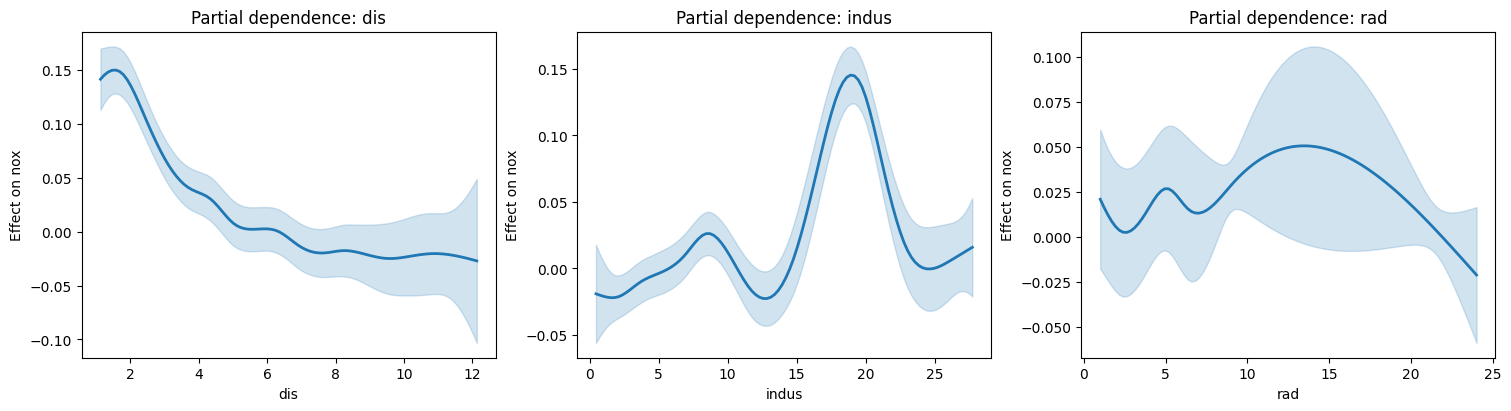

In [13]:
import matplotlib.pyplot as plt
from pygam import LinearGAM, s

X = boston_data[["dis", "indus", "rad"]].to_numpy()
y = boston_data["nox"].to_numpy()

# --- fit GAM with grid search over smoothing strength (lambda) ---
    # fitting spline terms 
gam = LinearGAM(s(0) + s(1) + s(2))
lam_grid = np.logspace(-3, 3, 11)
gam.gridsearch(X, y, lam=lam_grid)

print("Selected lam:", gam.lam)

# --- partial dependence plots ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
names = ["dis", "indus", "rad"]

# enumerate adds auto counter to any iterable 
for term, ax in enumerate(axes):
    XX = gam.generate_X_grid(term=term)
    pdep, ci = gam.partial_dependence(term=term, X=XX, width=0.95)

    x_axis = XX[:, term]
    ax.plot(x_axis, pdep, color="C0", lw=2)
    ax.fill_between(x_axis, ci[:, 0], ci[:, 1], color="C0", alpha=0.2)

    ax.set_title(f"Partial dependence: {names[term]}")
    ax.set_xlabel(names[term])
    ax.set_ylabel("Effect on nox")

plt.show()

### Partial Dependence Summary (GAM)

The partial dependence plots show the estimated smooth effects of each predictor on the linear predictor (log-odds scale), holding other variables fixed. 

- **`dis`**: Strong negative nonlinear relationship. The effect decreases sharply at small values and then levels off, indicating diminishing impact as distance increases. This suggests a potentially meaningful nonlinear effect. However, uncertainty increases at higher values, so extreme behavior should be interpreted cautiously.


- **`indus`**: Highly nonlinear and non-monotonic. There is a dip in the mid-range and a pronounced peak around 18–20. However, uncertainty increases at higher values, so extreme behavior should be interpreted cautiously.

- **`rad`**: Relatively weak and flatter effect compared to the others. The wide uncertainty bands suggest lower signal strength or sparse data in parts of the range.

Overall, the GAM captures substantial nonlinear structure—particularly for `dis` and `indus`—that would likely be missed by a purely linear model.

In [14]:
# Test assertions
# Verify the data was loaded correctly
assert boston_data is not None, "boston_data should be loaded"
assert "nox" in boston_data.columns, "boston_data should have nox column"
assert "indus" in boston_data.columns, "boston_data should have indus column"

# Verify GAM was fitted successfully
assert gam is not None, "GAM model should be defined"

print("All tests passed!")

All tests passed!
